# SQLite database

In [4]:
# install and import library
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# create a new SQLite Database and table
conn = sqlite3.connect("sales_data.db")

#Create a cursor to interact with database
cursor = conn.cursor()

# create a sample table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT NOT NULL,
    quantity INTEGER NOT NULL,
    price REAL NOT NULL,
    sale_date TEXT
)
""")

# commit and close the connection
conn.commit()

In [6]:
# enter sample data
sales = [
    ("Laptop", 2, 50000, "2026-01-10"),
    ("Laptop", 1, 52000, "2026-01-15"),
    ("Mouse", 5, 500, "2026-01-12"),
    ("Keyboard", 3, 1500, "2026-01-18"),
    ("Monitor", 2, 12000, "2026-01-20"),
    ("Mouse", 4, 550, "2026-02-02"),
    ("Laptop", 1, 51000, "2026-02-05"),
    ("Keyboard", 2, 1600, "2026-02-07"),
    ("Monitor", 1, 12500, "2026-02-10"),
    ("Headphones", 3, 2000, "2026-02-12")
]

# insert sales data in table
cursor.executemany("""
INSERT INTO sales (product, quantity, price, sale_date)
VALUES (?, ?, ?, ?)
""", sales)

# commit update
conn.commit()

In [11]:
# run SQL query
query = "select * from sales"
df = pd.read_sql(query, conn)

# print query
df

,id,product,quantity,price,sale_date
0,1,Laptop,2,50000.0,2026-01-10
1,2,Laptop,1,52000.0,2026-01-15
2,3,Mouse,5,500.0,2026-01-12
3,4,Keyboard,3,1500.0,2026-01-18
4,5,Monitor,2,12000.0,2026-01-20
5,6,Mouse,4,550.0,2026-02-02
6,7,Laptop,1,51000.0,2026-02-05
7,8,Keyboard,2,1600.0,2026-02-07
8,9,Monitor,1,12500.0,2026-02-10
9,10,Headphones,3,2000.0,2026-02-12


In [14]:
# run basic query
query = "SELECT product, SUM(quantity) AS total_qty, SUM(quantity * price) AS revenue FROM sales GROUP BY product"
df = pd.read_sql(query, conn)

# print query
df

,product,total_qty,revenue
0,Headphones,3,6000.0
1,Keyboard,5,7700.0
2,Laptop,4,203000.0
3,Monitor,3,36500.0
4,Mouse,9,4700.0


In [16]:
# quantity sold more than or equal to 4
query = "SELECT product, SUM(quantity) AS total_qty, SUM(quantity * price) AS revenue FROM sales GROUP BY product HAVING total_qty >= 4"
df = pd.read_sql(query, conn)

# print query
df

,product,total_qty,revenue
0,Keyboard,5,7700.0
1,Laptop,4,203000.0
2,Mouse,9,4700.0


DATA VISUALIZATION

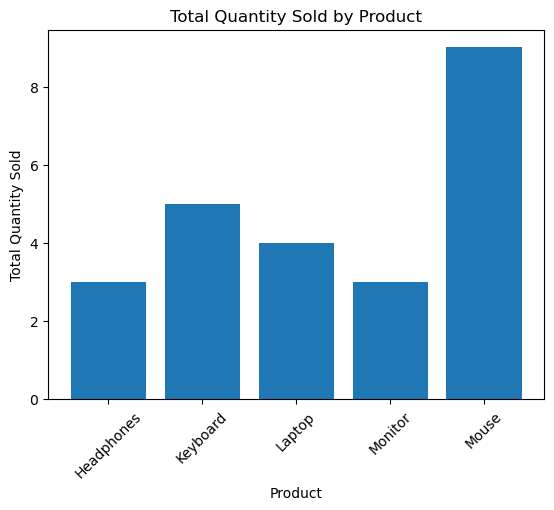

<Figure size 640x480 with 0 Axes>

In [22]:
# plot a bar chart Quantity Sold by Product
query = """ SELECT product, quantity, price, sale_date, quantity * price AS revenue FROM sales """
df = pd.read_sql_query(query, conn)

product_summary = df.groupby("product").agg({
    "quantity": "sum",
    "revenue": "sum"
}).reset_index()

plt.figure()
plt.bar(product_summary["product"], product_summary["quantity"])

plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.title("Total Quantity Sold by Product")
plt.xticks(rotation=45)

plt.show()

# save data to local machine
plt.savefig("Quantity Sold by Product.png")

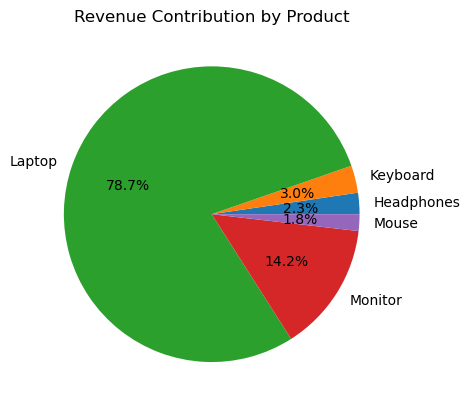

<Figure size 640x480 with 0 Axes>

In [23]:
# plot a pie chart revenue distribution
plt.figure()
plt.pie(product_summary["revenue"], labels=product_summary["product"], autopct="%1.1f%%")

plt.title("Revenue Contribution by Product")

plt.show()

# save data to local machine
plt.savefig("revenue distribution.png")